In [1]:
import sys
sys.path.append('/home/xinyiz/c2p_dag/')
sys.path.append('/home/xinyiz/c2p_dag/img2seq/')

import numpy as np
import pickle
import os
import pandas as pd
from scipy import sparse

import time

import scanpy
import numpy as np

import torch
from torch import optim


import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

import anndata as ad
import gc


import gae.gae.optimizer as optimizer

import gae.gae.model
import gae.gae.model_lord
import gae.gae.preprocessing as preprocessing

2025-05-26 22:27:52.225289: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
nSamples= 2048

Z1 = np.random.binomial(1, 0.5, size=nSamples)

gamma2 = np.random.gamma(shape=5, scale=1, size=nSamples)
Z2 = Z1 + gamma2 * np.sqrt(0.0045) 

Z3 = np.random.binomial(1, 0.5, size=nSamples)

gamma4 = np.random.gamma(shape=2, scale=2, size=nSamples)
Z4 = 2 * Z2 + Z3 + gamma4 * np.sqrt(0.00125)

gamma5 = np.random.gamma(shape=3, scale=2, size=nSamples)
Z5 = Z2 + gamma5 * np.sqrt(0.0075)

Z = np.stack([Z1, Z2, Z3, Z4, Z5], axis=1)

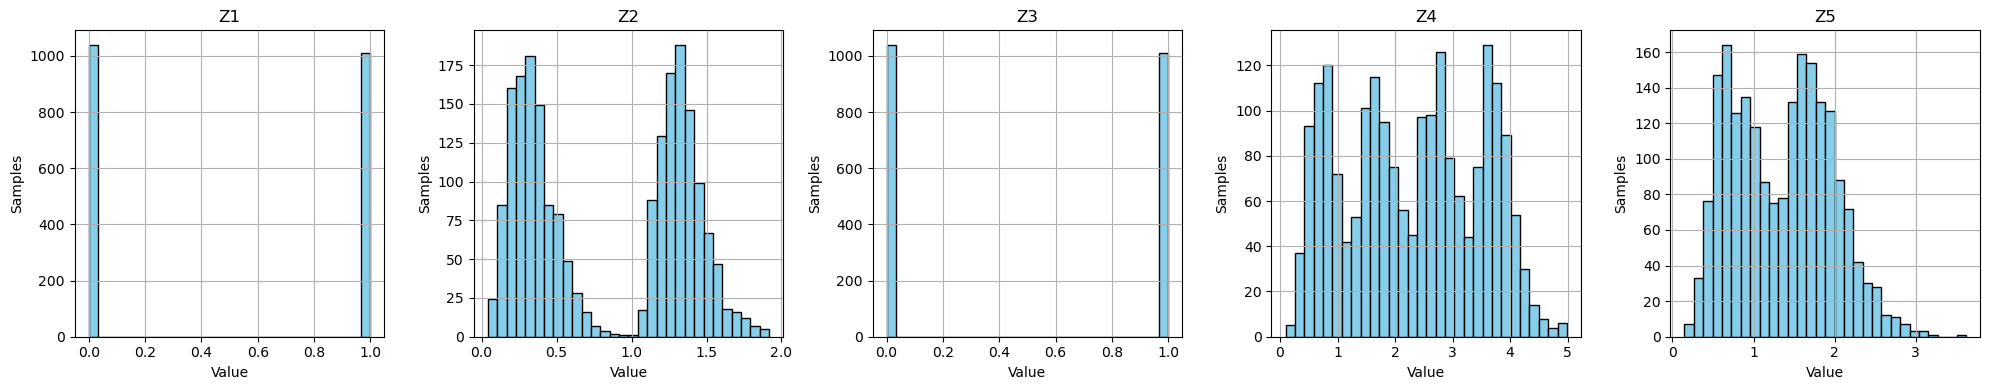

In [126]:
variables = [Z1, Z2, Z3, Z4, Z5]
titles = ['Z1', 'Z2', 'Z3', 'Z4', 'Z5']

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, (z, title) in enumerate(zip(variables, titles)):
    axs[i].hist(z, bins=30, color='skyblue', edgecolor='black')
    axs[i].set_title(title)
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Samples')
    axs[i].grid(True)

plt.tight_layout()
plt.savefig('z_distribution.pdf')
plt.show()

In [4]:
Z

array([[0.        , 0.16161705, 0.        , 0.39743965, 0.5044351 ],
       [0.        , 0.40307347, 0.        , 0.89160526, 1.0563456 ],
       [0.        , 0.23464318, 1.        , 1.58100275, 0.81351483],
       ...,
       [1.        , 1.19447753, 1.        , 3.44990763, 1.42697924],
       [1.        , 1.36823788, 1.        , 3.93919621, 1.73770241],
       [1.        , 1.39919541, 0.        , 2.80862707, 1.71257539]])

In [5]:
X = np.zeros((nSamples, 80))

Z_X = np.stack([Z1, Z2, Z3, Z4], axis=1)

# X1-X10: pure children of Z4
G1 = np.random.randn(10, 1)
X[:, 0:10] = Z_X[:, [3]] @ G1.T

# X11-X20: pure children of Z3
G2 = np.random.randn(10, 1)
X[:, 10:20] = Z_X[:, [2]] @ G2.T

# X21-X30: pure children of Z2
G3 = np.random.randn(10, 1)
X[:, 20:30] = Z_X[:, [1]] @ G3.T

# X31-X40: children of Z2 and Z3
G4 = np.random.randn(10, 2)
X[:, 30:40] = Z_X[:, [1, 2]] @ G4.T

# X41-X50: children of Z2 and Z4
G5 = np.random.randn(10, 2)
X[:, 40:50] = Z_X[:, [1, 3]] @ G5.T

# X51-X60: children of Z3 and Z4
G6 = np.random.randn(10, 2)
X[:, 50:60] = Z_X[:, [2, 3]] @ G6.T

# X61-X70: children of Z2, Z3, Z4
G7 = np.random.randn(10, 3)
X[:, 60:70] = Z_X[:, [1, 2, 3]] @ G7.T

G8 = np.random.randn(10, 4)
X[:, 70:80] = Z_X @ G8.T

Y = np.zeros((nSamples, 40))

Z_Y = np.stack([Z1, Z2, Z5], axis=1)

GY1 = np.random.randn(10, 1)
Y[:, 0:10] = Z_Y[:, [2]] @ GY1.T

GY2 = np.random.randn(10, 1)
Y[:, 10:20] = Z_Y[:, [1]] @ GY2.T

GY3 = np.random.randn(10, 2)
Y[:, 20:30] = Z_Y[:, [1, 2]] @ GY3.T

GY4 = np.random.randn(10, 3)
Y[:, 30:40] = Z_Y @ GY4.T

In [78]:
#train-test split
np.random.seed(3)
pctVal=0.05
pctTest=0.1

allIdx_all=np.arange(nSamples)
np.random.shuffle(allIdx_all)
valIdx_all=allIdx_all[:int(pctVal*nSamples)]
testIdx_all=allIdx_all[int(pctVal*nSamples):(int(pctVal*nSamples)+int(pctTest*nSamples))]
trainIdx_all=allIdx_all[(int(pctVal*nSamples)+int(pctTest*nSamples)):]

hiddenSize=20
sharedSize=2
dSpecificSize=2
seed=1
#test0: 5, 3

In [79]:
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
os.environ["CUDA_LAUNCH_BLOCKING"] = "2"
 

batchsize=256
saveFreq=100
epochs=8000
lr_latent=0.001
lr_decoder=0.0001
weight_decay=0

dropout=0.01
XreconWeight=20
ridgeL=0.01

addNoise=True
actDecay=0.001

testSaveName='lord_bce'
name='test1_noSharedRecon'
logsavepath=os.path.join('/data/xinyi/c2p/simulation/results/log',testSaveName,name)
modelsavepath=os.path.join('/data/xinyi/c2p/simulation/results/models',testSaveName,name)
plotsavepath=os.path.join('/data/xinyi/c2p/simulation/results/plots',testSaveName,name)

loss_x=torch.nn.MSELoss()
loss_y=torch.nn.MSELoss()

In [80]:
if not os.path.exists(os.path.join('/data/xinyi/c2p/simulation/results/plots',testSaveName)):
    os.mkdir(os.path.join('/data/xinyi/c2p/simulation/results/plots',testSaveName))
    os.mkdir(os.path.join('/data/xinyi/c2p/simulation/results/models',testSaveName))
    os.mkdir(os.path.join('/data/xinyi/c2p/simulation/results/log',testSaveName))
if not os.path.exists(logsavepath):
    os.mkdir(logsavepath)
if not os.path.exists(modelsavepath):
    os.mkdir(modelsavepath)
if not os.path.exists(plotsavepath):
    os.mkdir(plotsavepath)
nFeatures_x=X.shape[1]
nFeatures_y=Y.shape[1]

In [81]:
def train(epoch):
    t = time.time()
    model_x.train()
    model_y.train()
    
    loss_all=0
    loss_x_train_all_x=0
    loss_x_train_all_y=0
    loss_lNorm_all=0
    loss_lNorm_all_x=0
    loss_lNorm_all_y=0
    
    ntrainBatches=int(np.ceil(trainIdx_all.shape[0]/batchsize))
    for i in range(ntrainBatches):
#         if i%200==0:
#             print(i)
        trainIdx=trainIdx_all[i*batchsize:min((i+1)*batchsize,trainIdx_all.shape[0])]
        traintarget_x=torch.tensor(X[trainIdx]).cuda().float()
        traintarget_y=torch.tensor(Y[trainIdx]).cuda().float()
        trainIdx=torch.tensor(trainIdx)
        trainInput_shared=latent_shared(trainIdx).cuda().float()
        trainInput_x=latent_x(trainIdx).cuda().float()
        trainInput_y=latent_y(trainIdx).cuda().float()

        if addNoise:
            trainInput_shared=trainInput_shared+torch.randn_like(trainInput_shared)
            trainInput_x=trainInput_x+torch.randn_like(trainInput_x)
            trainInput_y=trainInput_y+torch.randn_like(trainInput_y)
            
        optimizer_x.zero_grad()
        optimizer_latent.zero_grad()
        optimizer_y.zero_grad()

        recon_x= model_x(torch.cat((trainInput_shared,trainInput_x),dim=1))
        y_recon = model_y(torch.cat((trainInput_shared,trainInput_y),dim=1))

        loss_x_train_x=loss_x(recon_x, traintarget_x)
        loss_x_train_y=loss_y(y_recon, traintarget_y)        
        loss=loss_x_train_x+loss_x_train_y
        
        if addNoise:
            loss_lNorm=torch.mean(torch.linalg.norm(latent_shared(trainIdx).cuda(),dim=1))/latent_shared.embedding_dim
            loss_lNorm_all+=loss_lNorm.item()
            loss+=loss_lNorm*actDecay
            
            loss_lNorm_x=torch.mean(torch.linalg.norm(latent_x(trainIdx).cuda(),dim=1))/latent_x.embedding_dim
            loss_lNorm_all_x+=loss_lNorm_x.item()
            loss+=loss_lNorm_x*actDecay
            
            loss_lNorm_y=torch.mean(torch.linalg.norm(latent_y(trainIdx).cuda(),dim=1))/latent_y.embedding_dim
            loss_lNorm_all_y+=loss_lNorm_y.item()
            loss+=loss_lNorm_y*actDecay
            
        
        loss_x_train_all_y+=loss_x_train_y.item()
        loss_x_train_all_x+=loss_x_train_x.item()
        loss_all+=loss.item()
        
            
        loss.backward()
        optimizer_x.step()
        optimizer_latent.step()
        optimizer_y.step()


    loss_x_train_all_y=loss_x_train_all_y/ntrainBatches
    loss_x_train_all_x=loss_x_train_all_x/ntrainBatches
    loss_all=loss_all/ntrainBatches
    if addNoise:
        loss_lNorm_all=loss_lNorm_all/ntrainBatches
        loss_lNorm_all_x=loss_lNorm_all_x/ntrainBatches
        loss_lNorm_all_y=loss_lNorm_all_y/ntrainBatches

    
    with torch.no_grad():
        model_x.eval()
        model_y.eval()
        loss_x_val_all_x=0
        loss_x_val_all_y=0
        loss_val_all=0
        nvalBatches=int(np.ceil(valIdx_all.shape[0]/batchsize))
        for i in range(nvalBatches):
            valIdx=valIdx_all[i*batchsize:min((i+1)*batchsize,valIdx_all.shape[0])]
            valtarget_x=torch.tensor(X[valIdx]).cuda().float()
            valtarget_y=torch.tensor(Y[valIdx]).cuda().float()
            valIdx=torch.tensor(valIdx)
            valInput_shared=latent_shared(valIdx).cuda().float()
            valInput_x=latent_x(valIdx).cuda().float()
            valInput_y=latent_y(valIdx).cuda().float()

            recon_x= model_x(torch.cat((valInput_shared,valInput_x),dim=1))
            y_recon = model_y(torch.cat((valInput_shared,valInput_y),dim=1))

            loss_x_val_x=loss_x(recon_x, valtarget_x)
            loss_x_val_y=loss_y(y_recon, valtarget_y)


            loss=loss_x_val_x+loss_x_val_y
            
            loss_x_val_all_x+=loss_x_val_x.item()
            loss_x_val_all_y+=loss_x_val_y.item()
            loss_val_all+=loss.item()

        loss_x_val_all_x=loss_x_val_all_x/nvalBatches
        loss_x_val_all_y=loss_x_val_all_y/nvalBatches
        loss_val_all=loss_val_all/nvalBatches
    
    print(' Epoch: {:04d}'.format(epoch),
          'loss_train: {:.4f}'.format(loss_all),
          'loss_x_train_x: {:.4f}'.format(loss_x_train_all_x),
          'loss_x_train_y: {:.4f}'.format(loss_x_train_all_y),
          'loss_val: {:.4f}'.format(loss_val_all),
          'loss_x_val_x: {:.4f}'.format(loss_x_val_all_x),
          'loss_x_val_y: {:.4f}'.format(loss_x_val_all_y),
          'time: {:.4f}s'.format(time.time() - t))
    return loss_all,loss_x_train_all_x,loss_x_train_all_y,loss_val_all,loss_x_val_all_x,loss_x_val_all_y,loss_lNorm_all,loss_lNorm_all_x,loss_lNorm_all_y




In [82]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.enabled = True

model_x = gae.gae.model_lord.fc_decode_l4(nFeatures_x,sharedSize+dSpecificSize,hiddenSize, dropout)
model_y = gae.gae.model_lord.fc_decode_l4(nFeatures_y, sharedSize+dSpecificSize,hiddenSize, dropout)


model_x.cuda()
model_y.cuda()

optimizer_x = optim.Adam(model_x.parameters(), lr=lr_decoder, weight_decay=weight_decay)
optimizer_y = optim.Adam(model_y.parameters(), lr=lr_decoder, weight_decay=weight_decay)

latent_shared=torch.nn.Embedding(X.shape[0],sharedSize)
latent_x=torch.nn.Embedding(X.shape[0],dSpecificSize)
latent_y=torch.nn.Embedding(X.shape[0],dSpecificSize)
optimizer_latent= torch.optim.Adam([latent_shared.weight,latent_x.weight,latent_y.weight], lr=lr_latent, weight_decay=weight_decay)

train_loss=[np.inf]*(epochs)
val_loss=[np.inf]*(epochs)

train_loss_x=[np.inf]*(epochs)
val_loss_x=[np.inf]*(epochs)

train_loss_y=[np.inf]*(epochs)
val_loss_y=[np.inf]*(epochs)

train_lNorm=[np.inf]*(epochs)
train_lNorm_x=[np.inf]*(epochs)
train_lNorm_y=[np.inf]*(epochs)

t_ep=time.time()

for ep in range(epochs):

    train_loss[ep],train_loss_x[ep],train_loss_y[ep],val_loss[ep],val_loss_x[ep],val_loss_y[ep],train_lNorm[ep],train_lNorm_x[ep],train_lNorm_y[ep]=train(ep)


    if ep%saveFreq == 0 and ep != 0:
        torch.save(model_x.cpu().state_dict(), os.path.join(modelsavepath,str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(ep)+'_x.pt'))
        torch.save(model_y.cpu().state_dict(), os.path.join(modelsavepath,str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(ep)+'_y.pt'))

        with open(os.path.join(modelsavepath,'latentx_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(ep)), 'wb') as output:
            pickle.dump(latent_x.weight, output, pickle.HIGHEST_PROTOCOL)
        with open(os.path.join(modelsavepath,'latentShared_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(ep)), 'wb') as output:
            pickle.dump(latent_shared.weight, output, pickle.HIGHEST_PROTOCOL)
        with open(os.path.join(modelsavepath,'latenty_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(ep)), 'wb') as output:
            pickle.dump(latent_y.weight, output, pickle.HIGHEST_PROTOCOL)



    model_x.cuda()
    model_y.cuda()
    torch.cuda.empty_cache()
print(' total time: {:.4f}s'.format(time.time() - t_ep))





 Epoch: 0000 loss_train: 6.2021 loss_x_train_x: 4.2497 loss_x_train_y: 1.9505 loss_val: 5.4114 loss_x_val_x: 3.6094 loss_x_val_y: 1.8021 time: 0.0411s
 Epoch: 0001 loss_train: 6.1754 loss_x_train_x: 4.2352 loss_x_train_y: 1.9384 loss_val: 5.4028 loss_x_val_x: 3.6108 loss_x_val_y: 1.7920 time: 0.0369s
 Epoch: 0002 loss_train: 6.1454 loss_x_train_x: 4.2167 loss_x_train_y: 1.9268 loss_val: 5.3973 loss_x_val_x: 3.6107 loss_x_val_y: 1.7866 time: 0.0342s
 Epoch: 0003 loss_train: 6.1152 loss_x_train_x: 4.2007 loss_x_train_y: 1.9126 loss_val: 5.3933 loss_x_val_x: 3.6083 loss_x_val_y: 1.7851 time: 0.0339s
 Epoch: 0004 loss_train: 6.0824 loss_x_train_x: 4.1812 loss_x_train_y: 1.8993 loss_val: 5.3855 loss_x_val_x: 3.6018 loss_x_val_y: 1.7836 time: 0.0339s
 Epoch: 0005 loss_train: 6.0559 loss_x_train_x: 4.1657 loss_x_train_y: 1.8883 loss_val: 5.3765 loss_x_val_x: 3.5951 loss_x_val_y: 1.7814 time: 0.0338s
 Epoch: 0006 loss_train: 6.0279 loss_x_train_x: 4.1528 loss_x_train_y: 1.8732 loss_val: 5.3600

KeyboardInterrupt: 

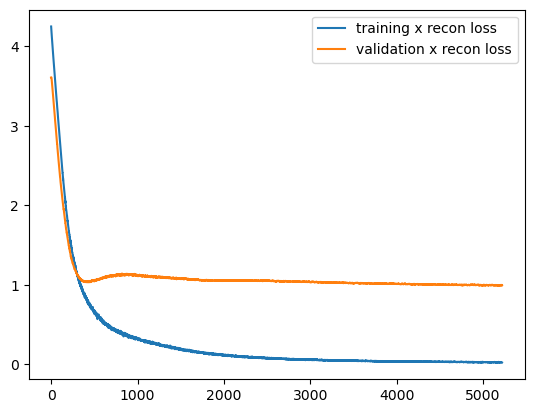

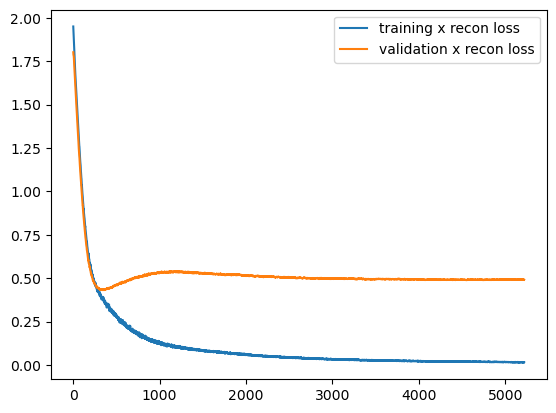

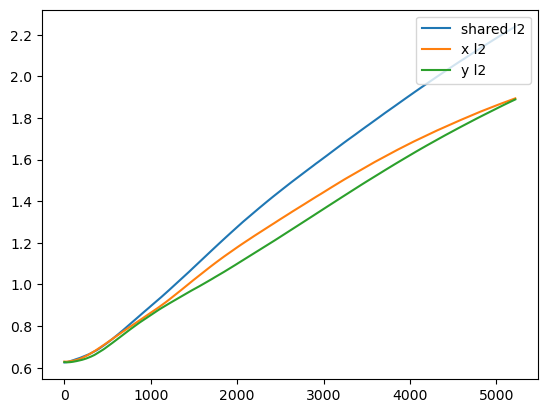

In [83]:
with open(os.path.join(logsavepath,'train_loss_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(train_loss, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'train_loss_x_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(train_loss_x, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'val_loss_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(val_loss, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'val_loss_x_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(val_loss_x, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'train_loss_y_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(train_loss_y, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'val_loss_y_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(val_loss_y, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'train_lNorm_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(train_lNorm, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'train_lNormx_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(train_lNorm_x, output, pickle.HIGHEST_PROTOCOL)
with open(os.path.join(logsavepath,'train_lNormy_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)), 'wb') as output:
    pickle.dump(train_lNorm_y, output, pickle.HIGHEST_PROTOCOL)



plt.plot(np.arange(epochs),train_loss_x)
plt.plot(np.arange(epochs),val_loss_x)
# plt.plot(np.arange(epochs),train_loss_kl_ep)
plt.legend(['training x recon loss','validation x recon loss','training kl loss'],loc='upper right')
plt.savefig(os.path.join(plotsavepath,'loss_x'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'.jpg'))
plt.show()



plt.plot(np.arange(epochs),train_loss_y)
plt.plot(np.arange(epochs),val_loss_y)
# plt.plot(np.arange(epochs),train_loss_kl_ep)
plt.legend(['training x recon loss','validation x recon loss','training kl loss'],loc='upper right')
plt.savefig(os.path.join(plotsavepath,'loss_y'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'.jpg'))
plt.show()


plt.plot(np.arange(epochs),train_lNorm)
plt.plot(np.arange(epochs),train_lNorm_x)
plt.plot(np.arange(epochs),train_lNorm_y)
# plt.plot(np.arange(epochs),train_loss_kl_ep)
plt.legend(['shared l2','x l2','y l2'],loc='upper right')
plt.savefig(os.path.join(plotsavepath,'loss_lNorm'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'.jpg'))
plt.show()



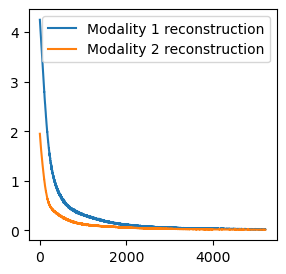

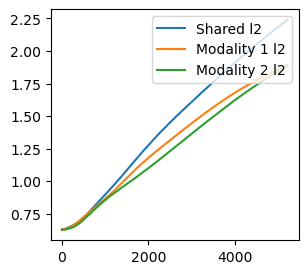

In [135]:
fig, ax = plt.subplots(figsize=(3.2,3))
plt.plot(np.arange(epochs),train_loss_x)
plt.plot(np.arange(epochs),train_loss_y)
# plt.plot(np.arange(epochs),val_loss_x)
# plt.plot(np.arange(epochs),train_loss_kl_ep)
plt.legend(['Modality 1 reconstruction','Modality 2 reconstruction','training kl loss'],loc='upper right')
plt.savefig(os.path.join(plotsavepath,'fig_loss_xy'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'.pdf'))
plt.show()

fig, ax = plt.subplots(figsize=(3.2,3))
plt.plot(np.arange(epochs),train_lNorm)
plt.plot(np.arange(epochs),train_lNorm_x)
plt.plot(np.arange(epochs),train_lNorm_y)
# plt.plot(np.arange(epochs),train_loss_kl_ep)
plt.legend(['Shared l2','Modality 1 l2','Modality 2 l2'],loc='upper right')
plt.savefig(os.path.join(plotsavepath,'fig_loss_lNorm'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'.pdf'))
plt.show()



In [110]:
latent_shared=torch.nn.Embedding(X.shape[0],sharedSize)
latent_x=torch.nn.Embedding(X.shape[0],dSpecificSize)
latent_y=torch.nn.Embedding(X.shape[0],dSpecificSize)

loadEpoch='1800'
with open(os.path.join(modelsavepath,'latentx_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(loadEpoch)), 'rb') as output:
    latent_x.weight=pickle.load(output)
with open(os.path.join(modelsavepath,'latentShared_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(loadEpoch)), 'rb') as output:
    latent_shared.weight=pickle.load( output)
with open(os.path.join(modelsavepath,'latenty_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed)+'_ep'+str(loadEpoch)), 'rb') as output:
    latent_y.weight=pickle.load(output)
latent_x.weight.requires_grad=False
latent_shared.weight.requires_grad=False
latent_y.weight.requires_grad=False


In [111]:
n_neighbors=10
min_dist=0.25

reducer_sharedlatent = umap.UMAP(n_neighbors=n_neighbors,min_dist=min_dist,random_state=3).fit(latent_shared.weight[trainIdx_all].cpu().detach())

In [127]:
def plotembeddingbyCT(ctlist,savename,excludelist,embedding,savepath,plotname,plotdimx=0,plotdimy=1,savenameAdd='',img=None,ncolors=None,colorseq=None,s=2.5):
    
    celltypes=np.unique(ctlist)

    if ncolors is None:
        colortest=sns.color_palette("husl", celltypes.size)
        if colorseq is None:
            colorseq=np.arange(celltypes.size)
    else:
        colortest=sns.color_palette("husl", ncolors)
        if colorseq is None:
            colorseq=np.arange(ncolors)

    
    fig, ax = plt.subplots(dpi=400)
    if not img is None:
        plt.imshow(img)
    for ct in celltypes:
        if ct in excludelist:
            continue
        idx=(ctlist==ct)
        if not img is None:
            ax.scatter(
                embedding[idx, plotdimy],
                embedding[idx, plotdimx],
                color=colortest[colorseq[int(ct)]],label=ct,s=1.5,alpha=0.5
                )
        else:
            ax.scatter(
                embedding[idx, plotdimx],
                embedding[idx, plotdimy],
                color=colortest[colorseq[int(ct)]],label=ct,s=s,alpha=1
                )

    plt.gca().set_aspect('equal', 'datalim')
    fig.set_figheight(5)
    fig.set_figwidth(5)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + box.height * 0.1,
                     box.width, box.height * 0.9])
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
              fancybox=True,ncol=5, shadow=True,prop={'size': 6})
    plt.title(plotname+' embedding', fontsize=12)
    plt.savefig(os.path.join(savepath,savename+savenameAdd+'.pdf'))
    plt.close('all')
    
def plotembeddingbyCT_str(ctlist,savename,excludelist,embedding,savepath,plotname,plotdimx=0,plotdimy=1,savenameAdd=''):
    celltypes=np.unique(ctlist)
    celltypes_dict={}
    idx=0
    for ct in celltypes:
        celltypes_dict[ct]=idx
        idx+=1
        
    colortest=sns.color_palette("husl", celltypes.size)
    fig, ax = plt.subplots(dpi=400)
    for ct in celltypes:
        if ct in excludelist:
            continue
        idx=(ctlist==ct)
        ax.scatter(
            embedding[idx, plotdimx],
            embedding[idx, plotdimy],
            color=colortest[celltypes_dict[ct]],label=ct,s=1,alpha=0.5
            )

    plt.gca().set_aspect('equal', 'datalim')
    fig.set_figheight(4)
    fig.set_figwidth(4)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0 + box.height * 0.3,
                     box.width, box.height * 0.7])
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
              fancybox=True, ncol=3, shadow=True, prop={'size': 6})
    plt.title(plotname, fontsize=12)
    plt.savefig(os.path.join(savepath,savename+savenameAdd+'.pdf'))
    plt.close('all')
    
    gc.collect()

In [128]:
plotembeddingbyCT_str(np.array(Z3[trainIdx_all]),'Z3_shared_latent',[],reducer_sharedlatent.embedding_,plotsavepath,'Z3',plotdimx=0,plotdimy=1,savenameAdd='_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed))


In [129]:
plotembeddingbyCT_str(np.array(Z1[trainIdx_all]),'Z1_shared_latent',[],reducer_sharedlatent.embedding_,plotsavepath,'Z1',plotdimx=0,plotdimy=1,savenameAdd='_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed))


In [114]:
reducer_ylatent = umap.UMAP(n_neighbors=n_neighbors,min_dist=min_dist,random_state=3).fit(latent_y.weight[trainIdx_all].cpu().detach())

In [130]:
plotembeddingbyCT_str(np.array(Z3[trainIdx_all]),'Z3_Y_latent',[],reducer_ylatent.embedding_,plotsavepath,'Z3',plotdimx=0,plotdimy=1,savenameAdd='_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed))
plotembeddingbyCT_str(np.array(Z1[trainIdx_all]),'Z1_Y_latent',[],reducer_ylatent.embedding_,plotsavepath,'Z1',plotdimx=0,plotdimy=1,savenameAdd='_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed))


In [116]:
reducer_xlatent = umap.UMAP(n_neighbors=n_neighbors,min_dist=min_dist,random_state=3).fit(latent_x.weight[trainIdx_all].cpu().detach())

In [131]:
plotembeddingbyCT_str(np.array(Z3[trainIdx_all]),'Z3_X_latent',[],reducer_xlatent.embedding_,plotsavepath,'Z3',plotdimx=0,plotdimy=1,savenameAdd='_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed))
plotembeddingbyCT_str(np.array(Z1[trainIdx_all]),'Z1_X_latent',[],reducer_xlatent.embedding_,plotsavepath,'Z1',plotdimx=0,plotdimy=1,savenameAdd='_'+str(sharedSize)+'_'+str(dSpecificSize)+'_'+str(hiddenSize)+'_'+str(seed))


In [118]:
from sklearn.metrics import silhouette_score

In [132]:
silhouette_score(latent_shared.weight[trainIdx_all].cpu().detach(),Z1[trainIdx_all])

0.55766535

In [121]:
silhouette_score(latent_shared.weight[trainIdx_all].cpu().detach(),Z3[trainIdx_all])

0.07794299

In [122]:
silhouette_score(latent_x.weight[trainIdx_all].cpu().detach(),Z3[trainIdx_all])

0.21951705

In [123]:
silhouette_score(latent_x.weight[trainIdx_all].cpu().detach(),Z1[trainIdx_all])

0.30039045

In [124]:
silhouette_score(latent_y.weight[trainIdx_all].cpu().detach(),Z1[trainIdx_all])

0.46526587

In [125]:
silhouette_score(latent_y.weight[trainIdx_all].cpu().detach(),Z3[trainIdx_all])

-0.00017943044